In [1]:
import sys
print(sys.executable)
print(sys.version)





c:\Users\rulit\Desktop\MachineLearning\Workshop_1\.venv\Scripts\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)

Pandas: 3.0.6
NumPy: 2.5.3
Scikit-learn: 1.9.1
Matplotlib: 3.11.2


In [3]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
)
from sklearn.preprocessing import OneHotEncoder

from pathlib import Path
import sys

# Encontrar la carpeta eda desde el notebook
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "eda" / "src" / "dataset.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EDA_DIR = PROJECT_ROOT / "eda"

if str(EDA_DIR) not in sys.path:
    sys.path.insert(0, str(EDA_DIR))

from src.dataset import load_split
from src.config import SEED, set_seeds

set_seeds()

print(f"Libraries loaded successfully. Random seed: {SEED}")

Libraries loaded successfully. Random seed: 42


In [4]:
train_df = load_split("train")
val_df = load_split("val")
test_df = load_split("test")

for name, split in (
    ("train", train_df),
    ("val", val_df),
    ("test", test_df)
):
    print(f"{name}: {len(split)} filas")
    print(f"Columnas: {list(split.columns)}")
    print()

train: 2997217 filas
Columnas: ['character_id', 'x', 'y', 'y_id']

val: 583098 filas
Columnas: ['character_id', 'x', 'y', 'y_id']

test: 644398 filas
Columnas: ['character_id', 'x', 'y', 'y_id']



In [5]:
CONTEXT_LENGTH = 5

MAX_TRAIN_ROWS = 30000
MAX_VAL_ROWS = 10000

train_sample = train_df.sample(
    n=min(MAX_TRAIN_ROWS, len(train_df)),
    random_state=42
)

validation_sample = val_df.sample(
    n=min(MAX_VAL_ROWS, len(val_df)),
    random_state=42
)

print("Train sample:", len(train_sample))
print("Validation sample:", len(validation_sample))

Train sample: 30000
Validation sample: 10000


In [6]:
def context_matrix(series, context_length):
    characters = [
        list(text[-context_length:])
        for text in series
    ]
    
    return np.asarray(characters, dtype=object)


X_train_chars = context_matrix(
    train_sample["x"],
    CONTEXT_LENGTH
)

X_val_chars = context_matrix(
    validation_sample["x"],
    CONTEXT_LENGTH
)

print("Form X_train:", X_train_chars.shape)
print("Form X_val:", X_val_chars.shape)

print("\nexamples:")
print(X_train_chars[0])

Form X_train: (30000, 5)
Form X_val: (10000, 5)

examples:
['A' 'n' 'd' ' ' 'f']


In [7]:
encoder = OneHotEncoder(handle_unknown="ignore")

X_train = encoder.fit_transform(X_train_chars)
X_val = encoder.transform(X_val_chars)

Y_train = train_sample["y_id"].to_numpy()
Y_val = validation_sample["y_id"].to_numpy()

print("X_train encoded shape:", X_train.shape)
print("X_val encoded shape:", X_val.shape)
print("Y_train shape:", Y_train.shape)
print("Y_val shape:", Y_val.shape)

X_train encoded shape: (30000, 317)
X_val encoded shape: (10000, 317)
Y_train shape: (30000,)
Y_val shape: (10000,)


In [8]:
logistic_model = LogisticRegression(
    C=1.0,
    solver="saga",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, Y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [9]:
Y_val_pred = logistic_model.predict(X_val)

print("Validation predictions generated.")
print("Number of predictions:", len(Y_val_pred))

Validation predictions generated.
Number of predictions: 10000


In [10]:
accuracy = accuracy_score(Y_val, Y_val_pred)

precision_macro = precision_score(
    Y_val,
    Y_val_pred,
    average="macro",
    zero_division=0
)

precision_weighted = precision_score(
    Y_val,
    Y_val_pred,
    average="weighted",
    zero_division=0
)

recall_macro = recall_score(
    Y_val,
    Y_val_pred,
    average="macro",
    zero_division=0
)

recall_weighted = recall_score(
    Y_val,
    Y_val_pred,
    average="weighted",
    zero_division=0
)

f1_macro = f1_score(
    Y_val,
    Y_val_pred,
    average="macro",
    zero_division=0
)

f1_weighted = f1_score(
    Y_val,
    Y_val_pred,
    average="weighted",
    zero_division=0
)

balanced_acc = balanced_accuracy_score(
    Y_val,
    Y_val_pred
)

print("Logistic Regression - Validation Metrics")
print("-----------------------------------------")
print(f"Accuracy:              {accuracy:.4f}")
print(f"Precision (macro):     {precision_macro:.4f}")
print(f"Precision (weighted):  {precision_weighted:.4f}")
print(f"Recall (macro):        {recall_macro:.4f}")
print(f"Recall (weighted):     {recall_weighted:.4f}")
print(f"F1 (macro):            {f1_macro:.4f}")
print(f"F1 (weighted):         {f1_weighted:.4f}")
print(f"Balanced Accuracy:     {balanced_acc:.4f}")

Logistic Regression - Validation Metrics
-----------------------------------------
Accuracy:              0.3720
Precision (macro):     0.1540
Precision (weighted):  0.3205
Recall (macro):        0.1060
Recall (weighted):     0.3720
F1 (macro):            0.1105
F1 (weighted):         0.3271
Balanced Accuracy:     0.1060


Confusion matrix shape: (60, 60)


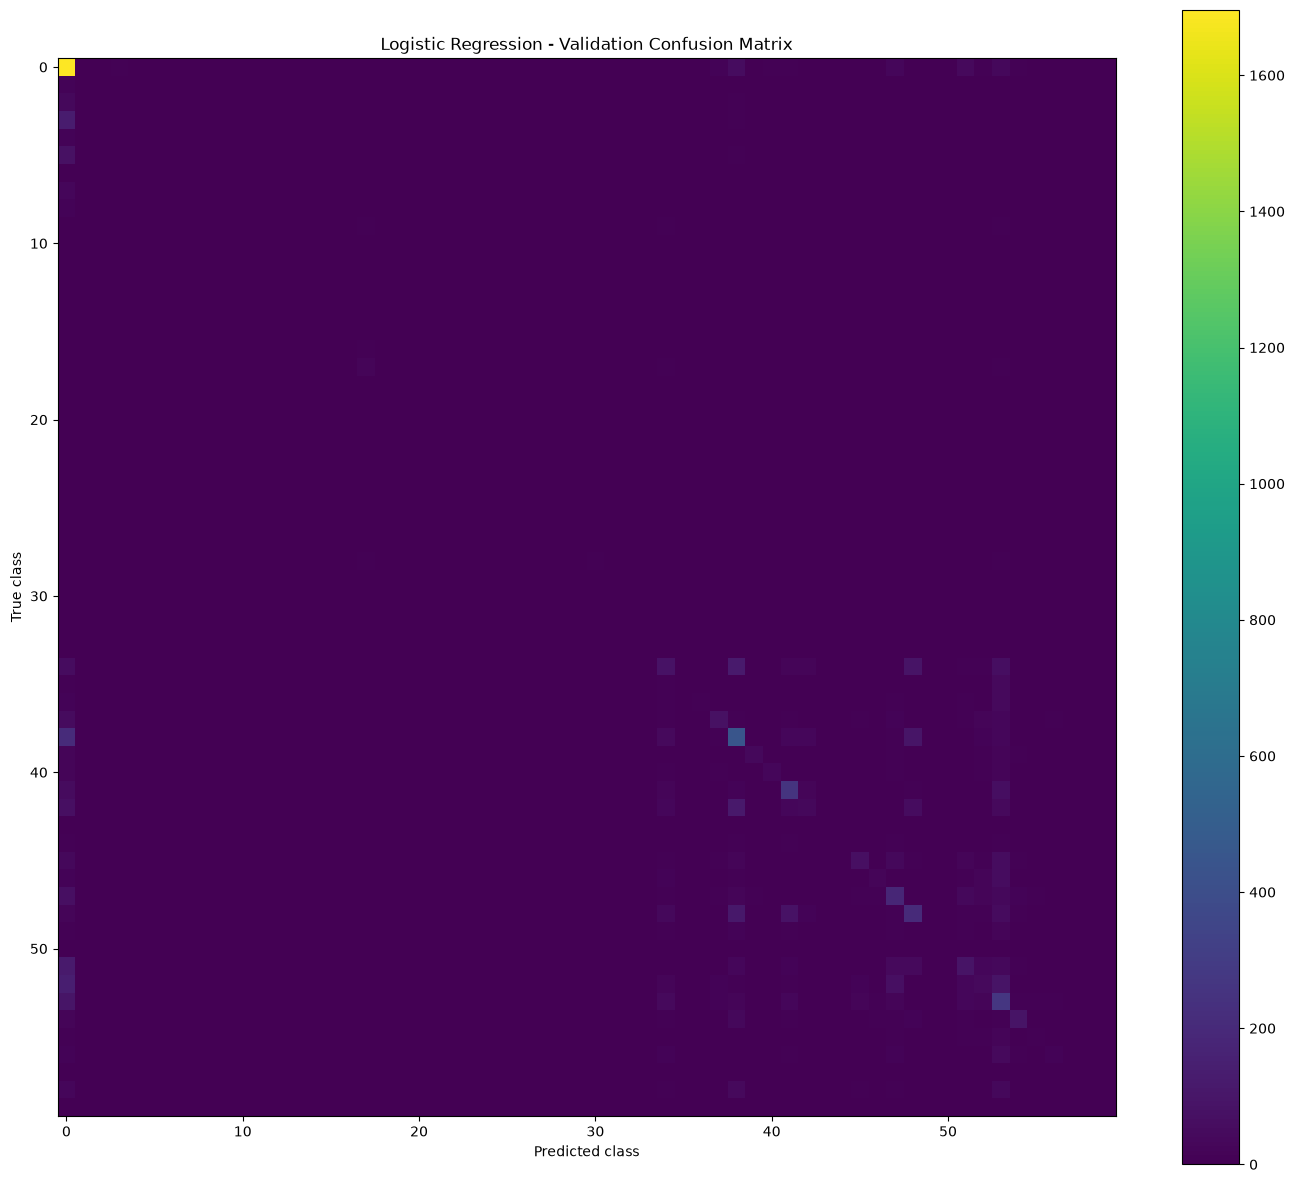

In [11]:
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_val, Y_val_pred)

print("Confusion matrix shape:", cm.shape)

plt.figure(figsize=(14, 12))
plt.imshow(cm, interpolation="nearest")
plt.title("Logistic Regression - Validation Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()
plt.tight_layout()
plt.show()

In [12]:
Y_val_proba = logistic_model.predict_proba(X_val)

print("Probability matrix shape:", Y_val_proba.shape)

Probability matrix shape: (10000, 64)


In [13]:
from sklearn.metrics import roc_auc_score

# Classes learned by the model
model_classes = logistic_model.classes_

# Keep only validation samples whose target class was learned by the model
known_mask = np.isin(Y_val, model_classes)

Y_val_auc = Y_val[known_mask]
Y_val_proba_auc = Y_val_proba[known_mask]

# Convert labels to the corresponding model class positions
class_to_index = {
    class_id: index
    for index, class_id in enumerate(model_classes)
}

Y_val_auc_index = np.array([
    class_to_index[class_id]
    for class_id in Y_val_auc
])

# Keep only classes that actually appear in validation
present_classes = np.unique(Y_val_auc_index)

Y_val_auc_binary = np.zeros(
    (len(Y_val_auc_index), len(present_classes))
)

for i, class_index in enumerate(present_classes):
    Y_val_auc_binary[:, i] = (
        Y_val_auc_index == class_index
    )

Y_val_proba_present = Y_val_proba_auc[:, present_classes]

auc_roc_macro = roc_auc_score(
    Y_val_auc_binary,
    Y_val_proba_present,
    average="macro",
    multi_class="ovr"
)

print("Logistic Regression - Validation AUC-ROC")
print("-----------------------------------------")
print(f"Macro AUC-ROC (OvR): {auc_roc_macro:.4f}")
print(f"Validation samples used: {len(Y_val_auc)}")
print(f"Classes evaluated: {len(present_classes)}")

Logistic Regression - Validation AUC-ROC
-----------------------------------------
Macro AUC-ROC (OvR): 0.8744
Validation samples used: 10000
Classes evaluated: 60


In [14]:
from sklearn.metrics import classification_report

report = classification_report(
    Y_val,
    Y_val_pred,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).T

print("Classification Report - Logistic Regression")
print("--------------------------------------------")

display(
    report_df[
        ["precision", "recall", "f1-score", "support"]
    ].round(4)
)

Classification Report - Logistic Regression
--------------------------------------------


,precision,recall,f1-score,support
1,0.5376,0.8675,0.6638,1955.000
2,0.0000,0.0000,0.0000,24.000
5,0.0000,0.0000,0.0000,55.000
8,0.2500,0.0282,0.0508,177.000
9,0.0000,0.0000,0.0000,20.000
...,...,...,...,...
73,0.0976,0.0225,0.0365,178.000
74,0.0000,0.0000,0.0000,2.000
accuracy,0.3720,0.3720,0.3720,0.372
macro avg,0.1540,0.1060,0.1105,10000.000


## Test Evaluation

In [15]:
MAX_TEST_ROWS = 10000

test_sample = test_df.sample(
    n=min(MAX_TEST_ROWS, len(test_df)),
    random_state=42
)

X_test_chars = context_matrix(
    test_sample["x"],
    CONTEXT_LENGTH
)

X_test = encoder.transform(X_test_chars)

Y_test = test_sample["y_id"].to_numpy()

print("Test sample:", len(test_sample))
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

Test sample: 10000
X_test shape: (10000, 317)
Y_test shape: (10000,)


In [16]:
Y_test_pred = logistic_model.predict(X_test)

print("Test predictions generated.")
print("Number of predictions:", len(Y_test_pred))

Test predictions generated.
Number of predictions: 10000


In [17]:
test_accuracy = accuracy_score(
    Y_test,
    Y_test_pred
)

test_precision_macro = precision_score(
    Y_test,
    Y_test_pred,
    average="macro",
    zero_division=0
)

test_recall_macro = recall_score(
    Y_test,
    Y_test_pred,
    average="macro",
    zero_division=0
)

test_f1_macro = f1_score(
    Y_test,
    Y_test_pred,
    average="macro",
    zero_division=0
)

test_precision_weighted = precision_score(
    Y_test,
    Y_test_pred,
    average="weighted",
    zero_division=0
)

test_recall_weighted = recall_score(
    Y_test,
    Y_test_pred,
    average="weighted",
    zero_division=0
)

test_f1_weighted = f1_score(
    Y_test,
    Y_test_pred,
    average="weighted",
    zero_division=0
)

test_balanced_accuracy = balanced_accuracy_score(
    Y_test,
    Y_test_pred
)

print("Logistic Regression - Test Metrics")
print("-----------------------------------")
print(f"Accuracy:              {test_accuracy:.4f}")
print(f"Precision (macro):     {test_precision_macro:.4f}")
print(f"Recall (macro):        {test_recall_macro:.4f}")
print(f"F1 (macro):            {test_f1_macro:.4f}")
print(f"Precision (weighted):  {test_precision_weighted:.4f}")
print(f"Recall (weighted):     {test_recall_weighted:.4f}")
print(f"F1 (weighted):         {test_f1_weighted:.4f}")
print(f"Balanced Accuracy:     {test_balanced_accuracy:.4f}")

Logistic Regression - Test Metrics
-----------------------------------
Accuracy:              0.3689
Precision (macro):     0.1575
Recall (macro):        0.1031
F1 (macro):            0.1082
Precision (weighted):  0.3180
Recall (weighted):     0.3689
F1 (weighted):         0.3236
Balanced Accuracy:     0.1031


In [18]:
Y_test_proba = logistic_model.predict_proba(X_test)

print("Test probability matrix shape:", Y_test_proba.shape)

Test probability matrix shape: (10000, 64)


In [19]:
from sklearn.metrics import roc_auc_score

model_classes = logistic_model.classes_

known_mask = np.isin(Y_test, model_classes)

Y_test_auc = Y_test[known_mask]
Y_test_proba_auc = Y_test_proba[known_mask]

class_to_index = {
    class_id: index
    for index, class_id in enumerate(model_classes)
}

Y_test_auc_index = np.array([
    class_to_index[class_id]
    for class_id in Y_test_auc
])

present_classes = np.unique(Y_test_auc_index)

Y_test_auc_binary = np.zeros(
    (len(Y_test_auc_index), len(present_classes))
)

for i, class_index in enumerate(present_classes):
    Y_test_auc_binary[:, i] = (
        Y_test_auc_index == class_index
    )

Y_test_proba_present = Y_test_proba_auc[:, present_classes]

auc_roc_test = roc_auc_score(
    Y_test_auc_binary,
    Y_test_proba_present,
    average="macro",
    multi_class="ovr"
)

print("Logistic Regression - Test AUC-ROC")
print("----------------------------------")
print(f"Macro AUC-ROC (OvR): {auc_roc_test:.4f}")
print(f"Test samples used: {len(Y_test_auc)}")
print(f"Classes evaluated: {len(present_classes)}")

Logistic Regression - Test AUC-ROC
----------------------------------
Macro AUC-ROC (OvR): 0.8710
Test samples used: 9998
Classes evaluated: 61


Test confusion matrix shape: (63, 63)


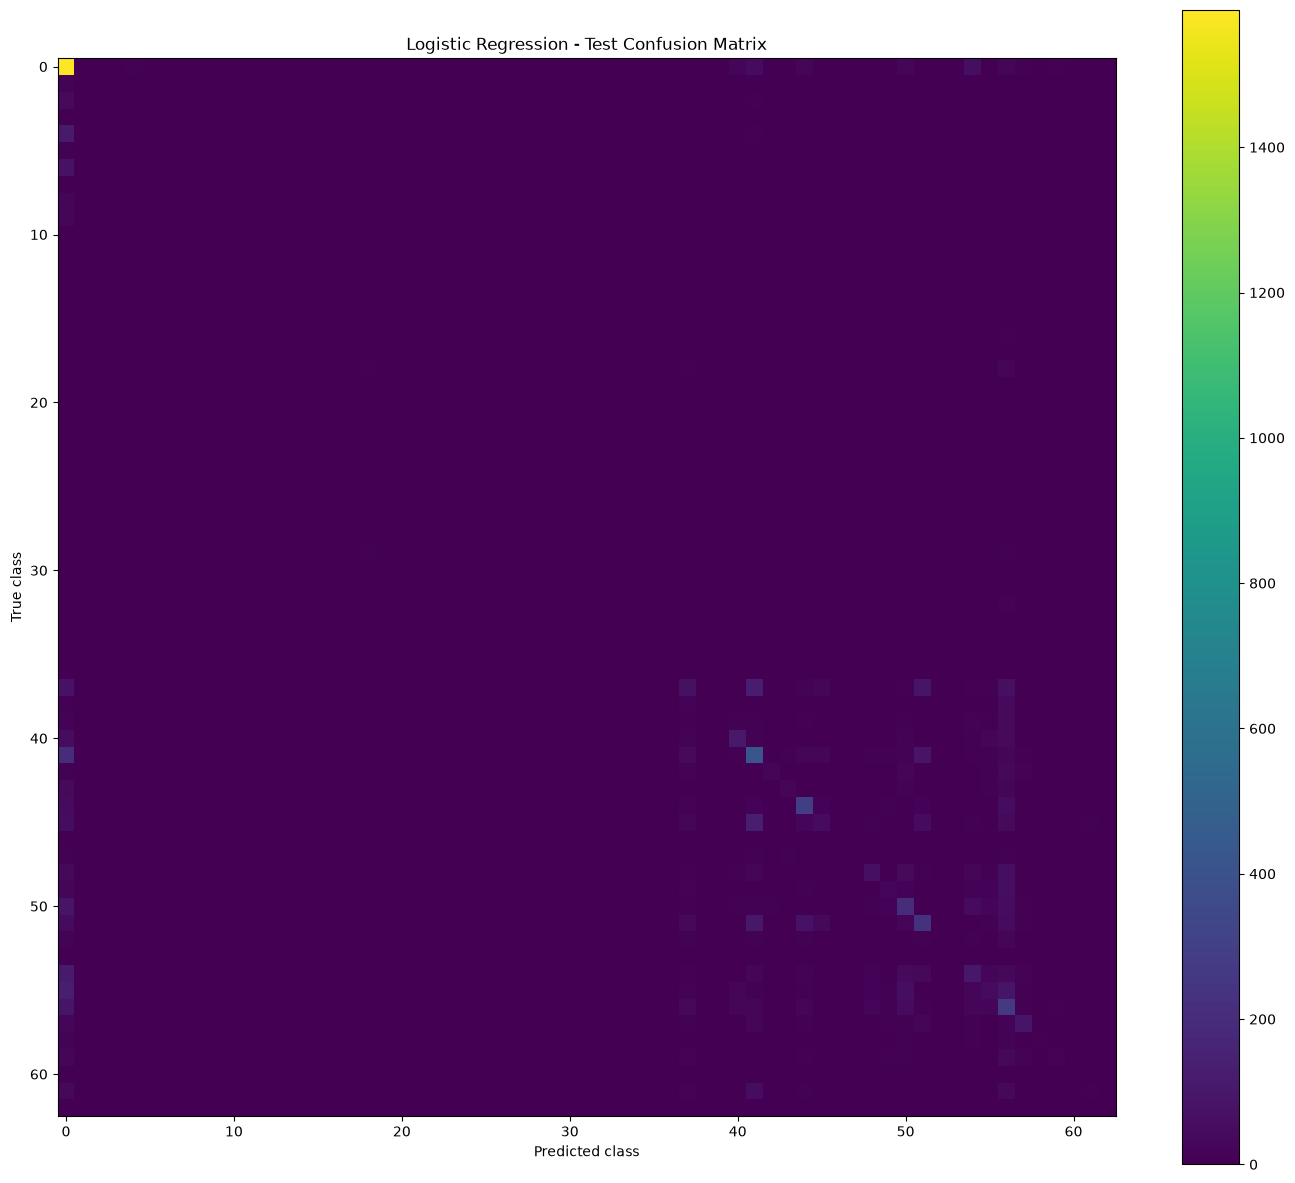

In [20]:
cm_test = confusion_matrix(
    Y_test,
    Y_test_pred
)

print("Test confusion matrix shape:", cm_test.shape)

plt.figure(figsize=(14, 12))
plt.imshow(cm_test, interpolation="nearest")
plt.title("Logistic Regression - Test Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()
plt.tight_layout()
plt.show()

Test confusion matrix shape: (63, 63)


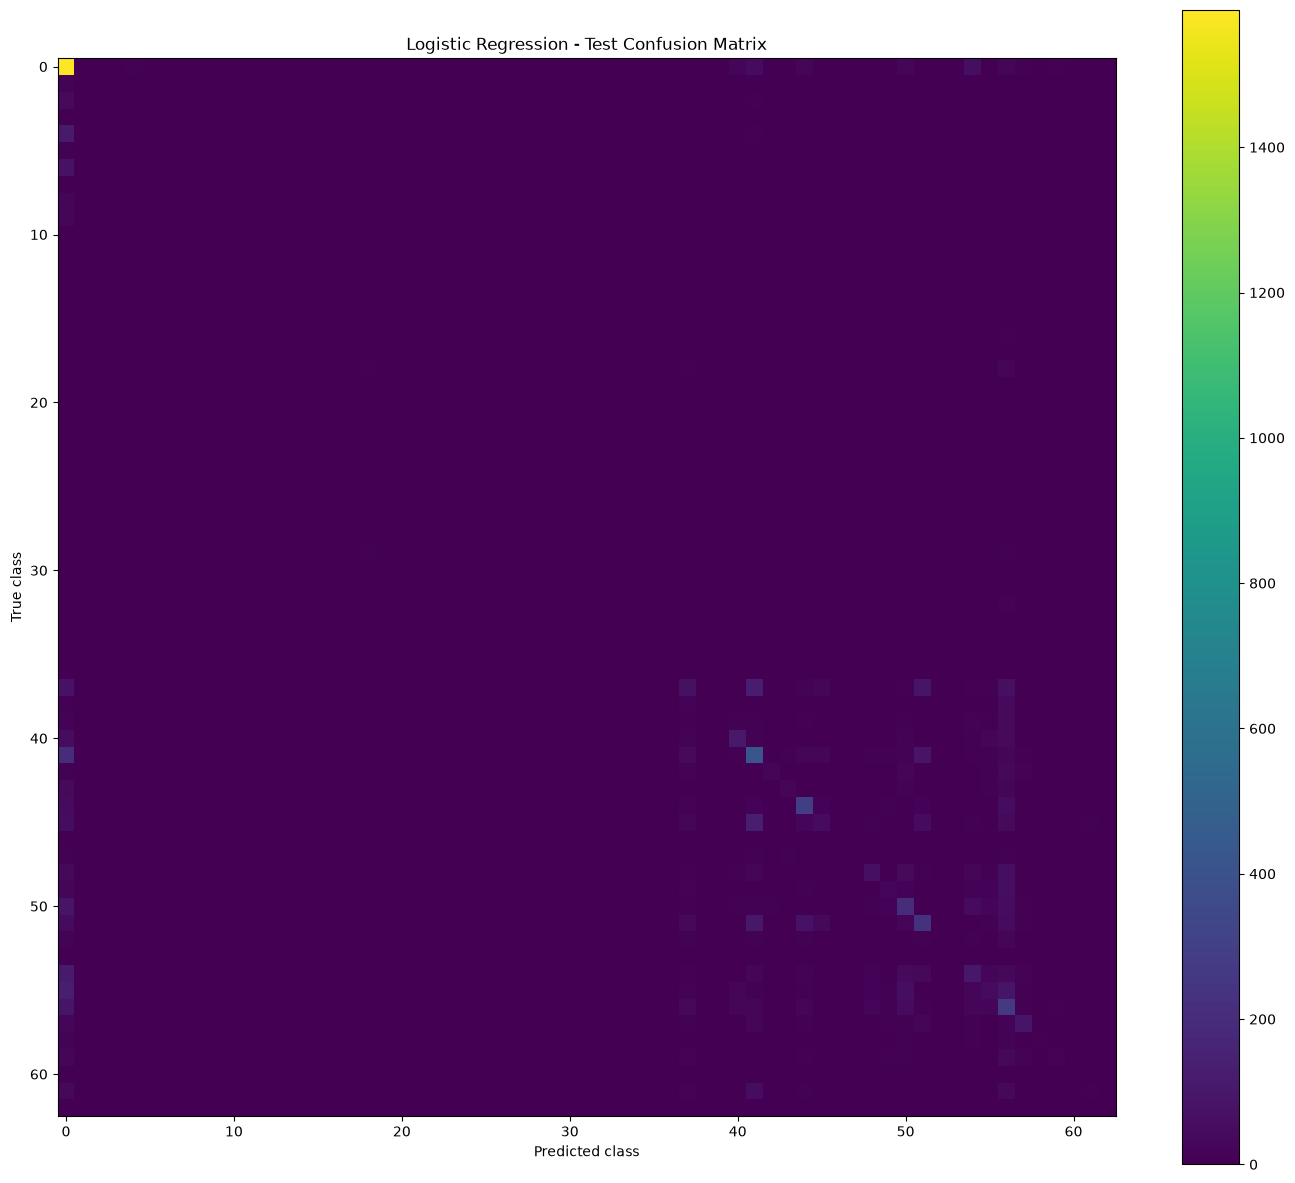

In [21]:
cm_test = confusion_matrix(Y_test, Y_test_pred)

print("Test confusion matrix shape:", cm_test.shape)

plt.figure(figsize=(14, 12))
plt.imshow(cm_test, interpolation="nearest")
plt.title("Logistic Regression - Test Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()
plt.tight_layout()
plt.show()

## Final Results Summary

In [22]:
results_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1 Score (Macro)",
        "Precision (Weighted)",
        "Recall (Weighted)",
        "F1 Score (Weighted)",
        "Balanced Accuracy",
        "Macro AUC-ROC"
    ],
    "Validation": [
        0.3720,
        0.1540,
        0.1060,
        0.1105,
        0.3205,
        0.3720,
        0.3271,
        0.1060,
        0.8744
    ],
    "Test": [
        0.3689,
        0.1575,
        0.1031,
        0.1082,
        0.3180,
        0.3689,
        0.3236,
        0.1031,
        0.8710
    ]
})

results_summary

,Metric,Validation,Test
0,Accuracy,0.3720,0.3689
1,Precision (Macro),0.1540,0.1575
2,Recall (Macro),0.1060,0.1031
3,F1 Score (Macro),0.1105,0.1082
4,Precision (Weighted),0.3205,0.3180
5,Recall (Weighted),0.3720,0.3689
6,F1 Score (Weighted),0.3271,0.3236
7,Balanced Accuracy,0.1060,0.1031
8,Macro AUC-ROC,0.8744,0.8710
